In [9]:
#链接数据库
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = Path(r"D:\quanttrade20260207\data\stockdata\daily_hfq_repaired.db")
assert db_path.exists(), f"找不到数据库：{db_path}"

con = sqlite3.connect(db_path.as_uri() + "?mode=ro", uri=True)
print("已连接：", db_path)

已连接： D:\quanttrade20260207\data\stockdata\daily_hfq_repaired.db


In [2]:
#查看有哪些表，以及 daily_quote 的字段类型
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name",
    con,
)
display(tables)

columns = pd.read_sql_query("PRAGMA table_info(daily_quote)", con)
display(columns[["name", "type", "notnull", "pk"]])

,name
0,corporate_action_factor
1,daily_quote
2,industry_master
3,industry_quote
4,ingestion_batch
5,repair_metadata
6,repair_quality_flags
7,repair_quarantined_daily
8,repair_security_audit
9,repair_source_meta


,name,type,notnull,pk
0,id,INTEGER,0,1
1,stock_code,TEXT,1,0
2,stock_name,TEXT,0,0
3,trade_date,TEXT,1,0
4,instrument_type,TEXT,1,0
5,adjustment,TEXT,1,0
6,source,TEXT,1,0
7,open_price,REAL,1,0
8,close_price,REAL,1,0
9,high_price,REAL,1,0


In [4]:
#看数据规模和日期范围
overview = pd.read_sql_query("""
    SELECT
        COUNT(*) AS 行数,
        COUNT(DISTINCT stock_code) AS 股票数,
        MIN(trade_date) AS 最早日期,
        MAX(trade_date) AS 最晚日期
    FROM daily_quote
    WHERE instrument_type = 'equity'
""", con)

display(overview)

,行数,股票数,最早日期,最晚日期
0,6894972,5298,2018-07-02,2024-12-31


In [5]:
#看 10 行原始数据
sample = pd.read_sql_query("""
    SELECT stock_code, stock_name, trade_date,
           open_price, high_price, low_price, close_price,
           volume, turnover, trade_status, adjustment, source
    FROM daily_quote
    WHERE instrument_type = 'equity'
    ORDER BY trade_date, stock_code
    LIMIT 10
""", con)

print("样本形状（行数, 列数）：", sample.shape)
display(sample)

样本形状（行数, 列数）： (10, 12)


,stock_code,stock_name,trade_date,open_price,high_price,low_price,close_price,volume,turnover,trade_status,adjustment,source
0,000001,平安银行,2018-07-02,1421.35,1421.35,1346.08,1355.12,131552013.0,1.158546e+09,None,hfq,tencent:ifzqgtimg/newfqkline/get
1,000002,万 科Ａ,2018-07-02,2737.15,2742.10,2540.94,2568.68,84620386.0,1.981132e+09,None,hfq,tencent:ifzqgtimg/newfqkline/get
2,000004,国华退,2018-07-02,146.81,146.81,141.37,142.97,221020.0,4.248500e+06,None,hfq,tencent:ifzqgtimg/newfqkline/get
3,000005,ST星源,2018-07-02,31.31,31.31,30.27,30.40,4248500.0,1.246750e+07,None,hfq,tencent:ifzqgtimg/newfqkline/get
4,000006,深振业Ａ,2018-07-02,428.49,431.05,402.89,407.37,15316858.0,8.625170e+07,None,hfq,tencent:ifzqgtimg/newfqkline/get
5,000007,全新好,2018-07-02,196.11,200.74,196.11,197.66,608400.0,8.056700e+06,None,hfq,tencent:ifzqgtimg/newfqkline/get
6,000009,中国宝安,2018-07-02,50.07,50.27,48.28,48.88,9470998.0,4.579090e+07,None,hfq,tencent:ifzqgtimg/newfqkline/get
7,000010,*ST美丽,2018-07-02,43.19,44.87,41.62,42.29,8137540.0,3.213830e+07,None,hfq,tencent:ifzqgtimg/newfqkline/get
8,000011,深物业A,2018-07-02,39.44,39.44,37.04,37.82,2998500.0,3.227200e+07,None,hfq,tencent:ifzqgtimg/newfqkline/get
9,000012,南 玻Ａ,2018-07-02,142.09,142.49,139.85,140.46,7386108.0,3.644260e+07,None,hfq,tencent:ifzqgtimg/newfqkline/get


In [7]:
#查看个股行情
stock_code = "000001"
start_date = "2024-01-01"
end_date = "2024-03-31"

quotes = pd.read_sql_query("""
    SELECT trade_date, stock_code, stock_name,
           open_price, high_price, low_price, close_price,
           volume, turnover
    FROM daily_quote
    WHERE instrument_type = 'equity'
      AND stock_code = ?
      AND trade_date BETWEEN ? AND ?
    ORDER BY trade_date
""", con, params=(stock_code, start_date, end_date))

print("查询结果形状：", quotes.shape)
display(quotes.head(10))

查询结果形状： (58, 9)


,trade_date,stock_code,stock_name,open_price,high_price,low_price,close_price,volume,turnover
0,2024-01-02,000001,平安银行,1651.97,1656.49,1624.88,1624.88,115836600.0,1.075742e+09
1,2024-01-03,000001,平安银行,1621.87,1626.38,1615.84,1623.37,73361000.0,6.736736e+08
2,2024-01-04,000001,平安银行,1621.87,1621.87,1605.31,1609.82,86419400.0,7.874701e+08
3,2024-01-05,000001,平安银行,1608.32,1659.50,1603.80,1633.91,199162200.0,1.852660e+09
4,2024-01-08,000001,平安银行,1627.89,1638.42,1609.82,1615.84,112115600.0,1.029006e+09
5,2024-01-09,000001,平安银行,1617.35,1621.87,1606.81,1620.36,76619400.0,7.003757e+08
6,2024-01-10,000001,平安银行,1617.35,1621.87,1606.81,1606.81,85862100.0,7.837712e+08
7,2024-01-11,000001,平安银行,1605.31,1626.38,1597.78,1618.86,93468600.0,8.538902e+08
8,2024-01-12,000001,平安银行,1612.83,1633.91,1609.82,1621.87,77258200.0,7.110183e+08
9,2024-01-15,000001,平安银行,1617.35,1636.92,1612.83,1624.88,74513300.0,6.859510e+08


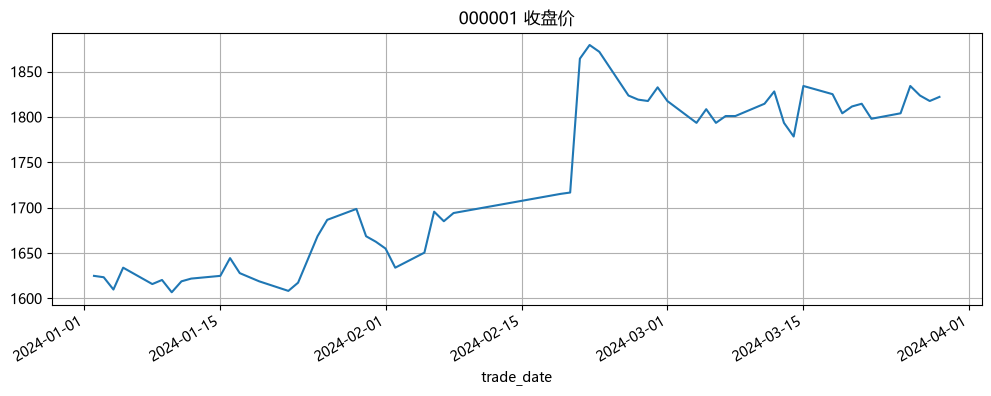

In [11]:
#画这只股票的收盘价
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

if quotes.empty:
    print("这个股票和日期区间没有数据")
else:
    chart = quotes.copy()
    chart["trade_date"] = pd.to_datetime(chart["trade_date"])
    chart.set_index("trade_date")["close_price"].plot(
        figsize=(12, 4),
        title=f"{stock_code} 收盘价",
        grid=True,
    )